# Analisis Dataset Log Akses Web (Granularitas Detik)
Notebook ini bertujuan untuk memproses data log akses HTTP mentah, mengekstrak informasi penting seperti timestamp, endpoint, HTTP status, dan response time, kemudian melakukan analisis data runtun waktu (time-series) untuk menghitung **Requests Per Second (RPS)** tingkat detik.

Hasil analisis ini akan menjadi landasan untuk merancang skenario pengujian beban (load testing) menggunakan Locust.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from datetime import datetime

# Set style untuk matplotlib
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12


In [2]:
import time

log_file_path = 'dataset/NASA_access_log_Jul95'

print("Membaca dan mem-parsing log file secara efisien...")
start_time = time.time()
data = []
with open(log_file_path, 'r', encoding='latin1') as f:
    for i, line in enumerate(f):
        try:
            parts = line.split('"')
            ts_start = parts[0].find('[') + 1
            ts_end = parts[0].find(']')
            ts_str = parts[0][ts_start:ts_end-6] # Potong '-0400'
            dt = datetime.strptime(ts_str, '%d/%b/%Y:%H:%M:%S')
            
            req_parts = parts[1].split()
            method = req_parts[0]
            endpoint = req_parts[1]
            
            status_size_parts = parts[2].strip().split()
            status = int(status_size_parts[0])
            size_str = status_size_parts[1]
            size = int(size_str) if size_str.isdigit() else 0
            
            data.append((dt, method, endpoint, status, size))
        except Exception:
            continue
        if (i + 1) % 500000 == 0:
            print(f"Selesai memproses {i + 1} baris...")

df = pd.DataFrame(data, columns=['datetime', 'method', 'endpoint', 'status', 'size_bytes'])
df['method'] = df['method'].astype('category')
df['endpoint'] = df['endpoint'].astype('category')
df['status'] = df['status'].astype('uint16')
df['size_bytes'] = df['size_bytes'].astype('uint32')

df.set_index('datetime', inplace=True)
df.sort_index(inplace=True)

print(f"Total baris log: {len(df)} (diproses dalam {time.time() - start_time:.2f} detik)")
df.head()


Membaca dan mem-parsing log file secara efisien...


Selesai memproses 500000 baris...


Selesai memproses 1000000 baris...


Selesai memproses 1500000 baris...


Total baris log: 1891695 (diproses dalam 33.09 detik)


,method,endpoint,status,size_bytes
datetime,,,,
1995-07-01 00:00:01,GET,/history/apollo/,200,6245
1995-07-01 00:00:06,GET,/shuttle/countdown/,200,3985
1995-07-01 00:00:09,GET,/shuttle/missions/sts-73/mission-sts-73.html,200,4085
1995-07-01 00:00:11,GET,/shuttle/countdown/liftoff.html,304,0
1995-07-01 00:00:11,GET,/shuttle/missions/sts-73/sts-73-patch-small.gif,200,4179


In [3]:
# Menampilkan informasi struktur dan penggunaan memori DataFrame
df.info()


<class 'pandas.DataFrame'>
DatetimeIndex: 1891695 entries, 1995-07-01 00:00:01 to 1995-07-28 13:32:25
Data columns (total 4 columns):
 #   Column      Dtype   
---  ------      -----   
 0   method      category
 1   endpoint    category
 2   status      uint16  
 3   size_bytes  uint32  
dtypes: category(2), uint16(1), uint32(1)
memory usage: 30.8 MB


Distribusi endpoint:
endpoint
/images/NASA-logosmall.gif                       111388
/images/KSC-logosmall.gif                         89639
/images/MOSAIC-logosmall.gif                      60468
/images/USA-logosmall.gif                         60014
/images/WORLD-logosmall.gif                       59489
                                                  ...  
/~www/pics/welcome.gif                                1
HTTP/1.0                                              1
htbin/cdt_clock.pl                                    1
http://www.ksc.nasa.gov:80/shuttle/countdown/         1
www.ksc.nasa.gov                                      1
Name: count, Length: 21212, dtype: int64


/tmp/ipykernel_1296695/3851890108.py:12: UserWarning: Glyph 24 () missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1296695/3851890108.py:12: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  plt.tight_layout()


/tmp/ipykernel_1296695/3851890108.py:12: UserWarning: Glyph 130 (\x82) missing from font(s) DejaVu Sans.
  plt.tight_layout()


/tmp/ipykernel_1296695/3851890108.py:12: UserWarning: Glyph 4 () missing from font(s) DejaVu Sans.
  plt.tight_layout()


/tmp/ipykernel_1296695/3851890108.py:12: UserWarning: Glyph 143 (\x8f) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1296695/3851890108.py:12: UserWarning: Glyph 138 (\x8a) missing from font(s) DejaVu Sans.
  plt.tight_layout()


...

/home/dimas/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 130 (\x82) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


/home/dimas/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 4 () missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


/home/dimas/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 143 (\x8f) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dimas/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 138 (\x8a) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


/home/dimas/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127 () missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


/home/dimas/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 134 (\x86) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


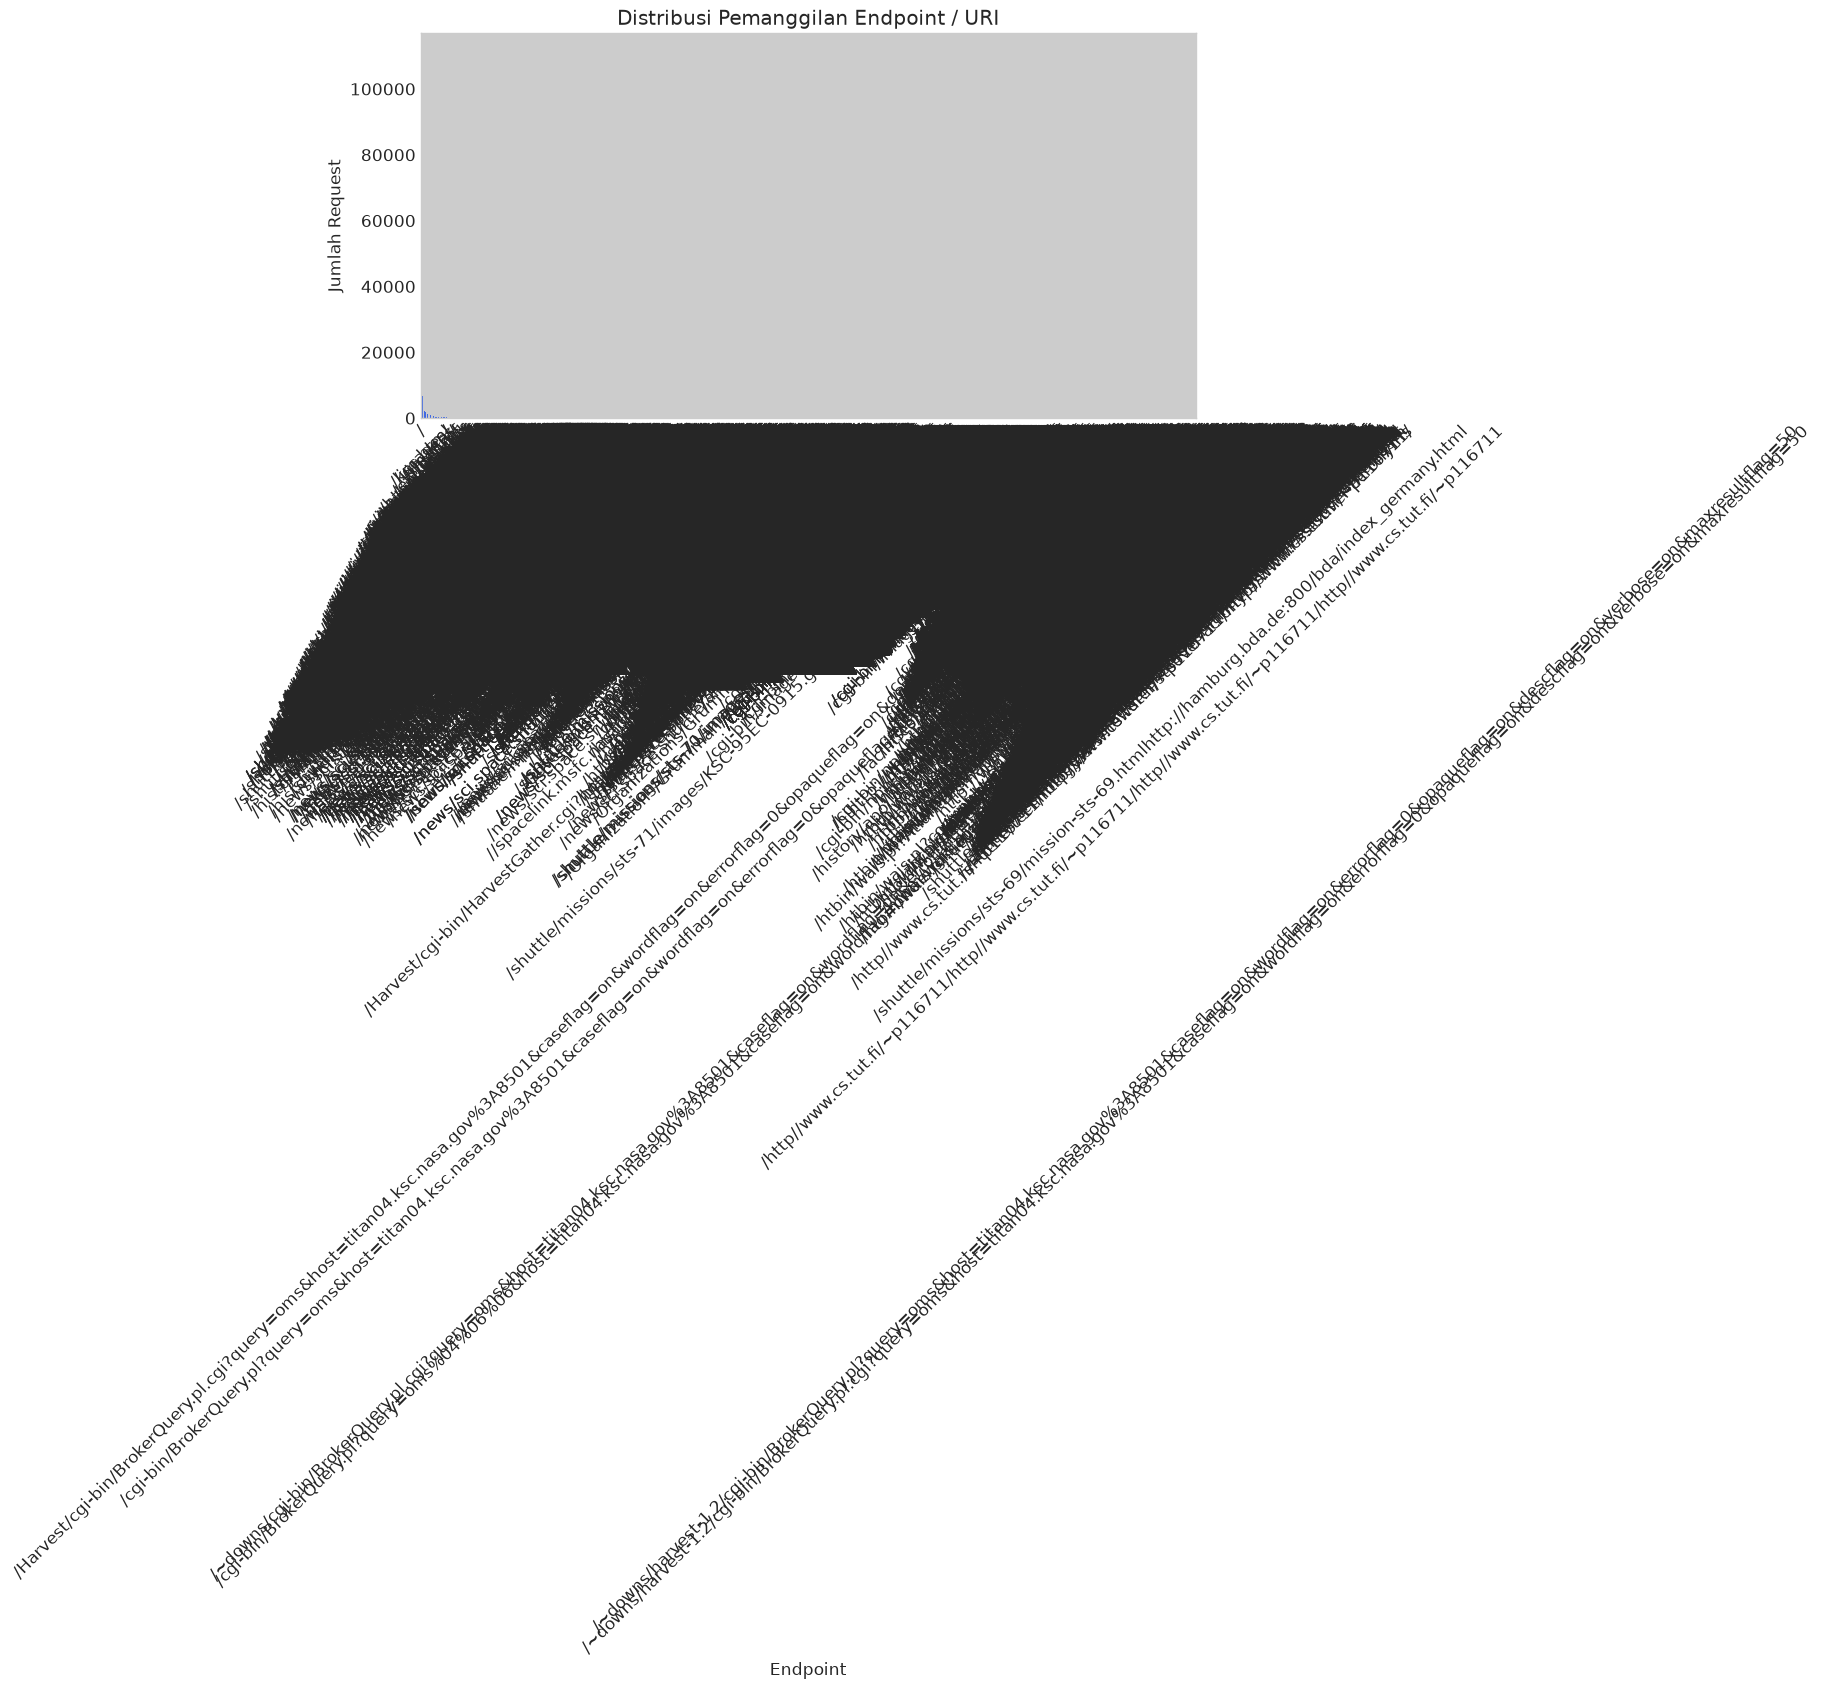

In [4]:
# Distribusi endpoint terpopuler
endpoint_counts = df['endpoint'].value_counts()
print("Distribusi endpoint:")
print(endpoint_counts)

plt.figure(figsize=(10, 5))
endpoint_counts.plot(kind='bar', color='royalblue')
plt.title('Distribusi Pemanggilan Endpoint / URI')
plt.xlabel('Endpoint')
plt.ylabel('Jumlah Request')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Distribusi HTTP Status Code:
status
200    1701534
304     132627
302      46573
404      10832
500         62
403         53
501         14
Name: count, dtype: int64


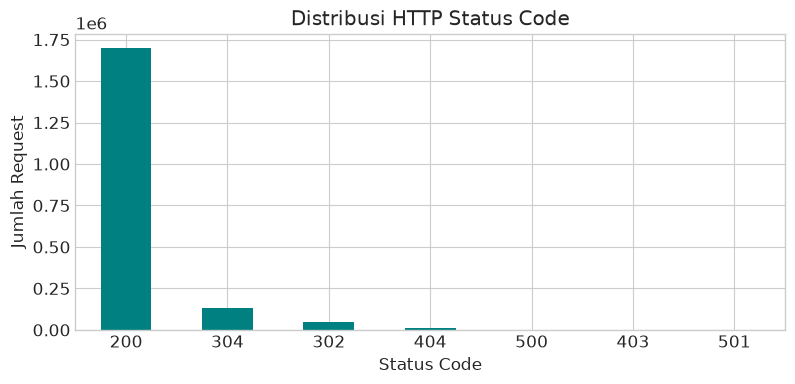

In [5]:
# Distribusi status code
status_counts = df['status'].value_counts()
print("Distribusi HTTP Status Code:")
print(status_counts)

plt.figure(figsize=(8, 4))
status_counts.plot(kind='bar', color='teal')
plt.title('Distribusi HTTP Status Code')
plt.xlabel('Status Code')
plt.ylabel('Jumlah Request')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [6]:
# Kita resample dengan interval 1 detik untuk menghitung total RPS
print("Menghitung total RPS per detik...")
total_rps = df.resample('1s').size()

# Hitung juga RPS per endpoint (hanya top 5, sisanya 'Others')
print("Menghitung RPS per-detik untuk top 5 endpoint...")
top_endpoints = df['endpoint'].value_counts().head(5).index.tolist()
plot_cols = top_endpoints + ['Others']

rps_per_endpoint = {}
for ep in top_endpoints:
    ep_df = df[df['endpoint'] == ep]
    rps_per_endpoint[ep] = ep_df.resample('1s').size().reindex(total_rps.index, fill_value=0)

# Sisanya dikelompokkan ke 'Others'
others_df = df[~df['endpoint'].isin(top_endpoints)]
rps_per_endpoint['Others'] = others_df.resample('1s').size().reindex(total_rps.index, fill_value=0)

# Masukkan ke dalam satu DataFrame
rps_df = pd.DataFrame(rps_per_endpoint)
rps_df['total_rps'] = total_rps
rps_df.head()


Menghitung total RPS per detik...


Menghitung RPS per-detik untuk top 5 endpoint...


,/images/NASA-logosmall.gif,/images/KSC-logosmall.gif,/images/MOSAIC-logosmall.gif,/images/USA-logosmall.gif,/images/WORLD-logosmall.gif,Others,total_rps
datetime,,,,,,,
1995-07-01 00:00:01,0,0,0,0,0,1,1
1995-07-01 00:00:02,0,0,0,0,0,0,0
1995-07-01 00:00:03,0,0,0,0,0,0,0
1995-07-01 00:00:04,0,0,0,0,0,0,0
1995-07-01 00:00:05,0,0,0,0,0,0,0


In [7]:
# Statistik Deskriptif RPS
stats = rps_df.describe()
print("Statistik Deskriptif RPS per-detik:")
print(stats.loc[['min', 'mean', 'max']])


Statistik Deskriptif RPS per-detik:
      /images/NASA-logosmall.gif  /images/KSC-logosmall.gif  \
min                     0.000000                   0.000000   
mean                    0.046771                   0.037639   
max                     5.000000                   4.000000   

      /images/MOSAIC-logosmall.gif  /images/USA-logosmall.gif  \
min                        0.00000                     0.0000   
mean                       0.02539                     0.0252   
max                        3.00000                     4.0000   

      /images/WORLD-logosmall.gif     Others  total_rps  
min                      0.000000   0.000000   0.000000  
mean                     0.024979   0.634335   0.794314  
max                      4.000000  20.000000  20.000000  


/tmp/ipykernel_1296695/2571678521.py:11: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


/home/dimas/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


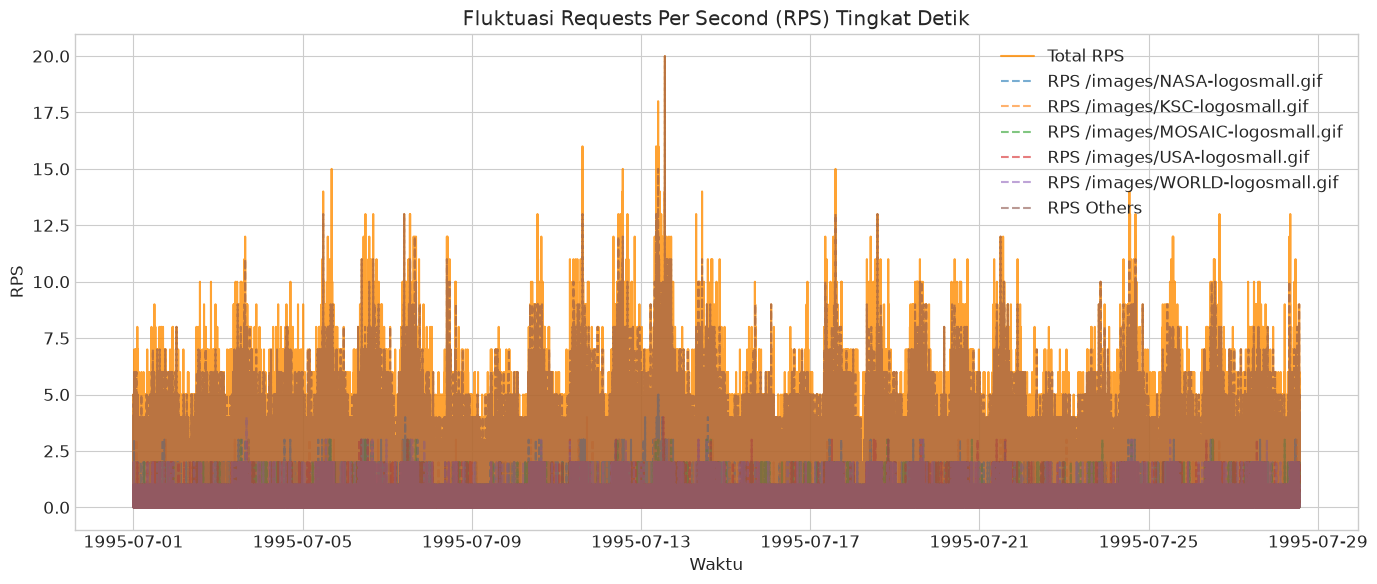

In [8]:
# Plot total RPS dari waktu ke waktu
plt.figure(figsize=(14, 6))
plt.plot(rps_df.index, rps_df['total_rps'], label='Total RPS', color='darkorange', alpha=0.8)
for ep in plot_cols:
    plt.plot(rps_df.index, rps_df[ep], label=f'RPS {ep}', alpha=0.6, linestyle='--')

plt.title('Fluktuasi Requests Per Second (RPS) Tingkat Detik')
plt.xlabel('Waktu')
plt.ylabel('RPS')
plt.legend()
plt.tight_layout()
plt.show()


Trafik puncak terjadi pada: 1995-07-13 13:32:58 dengan 20 RPS


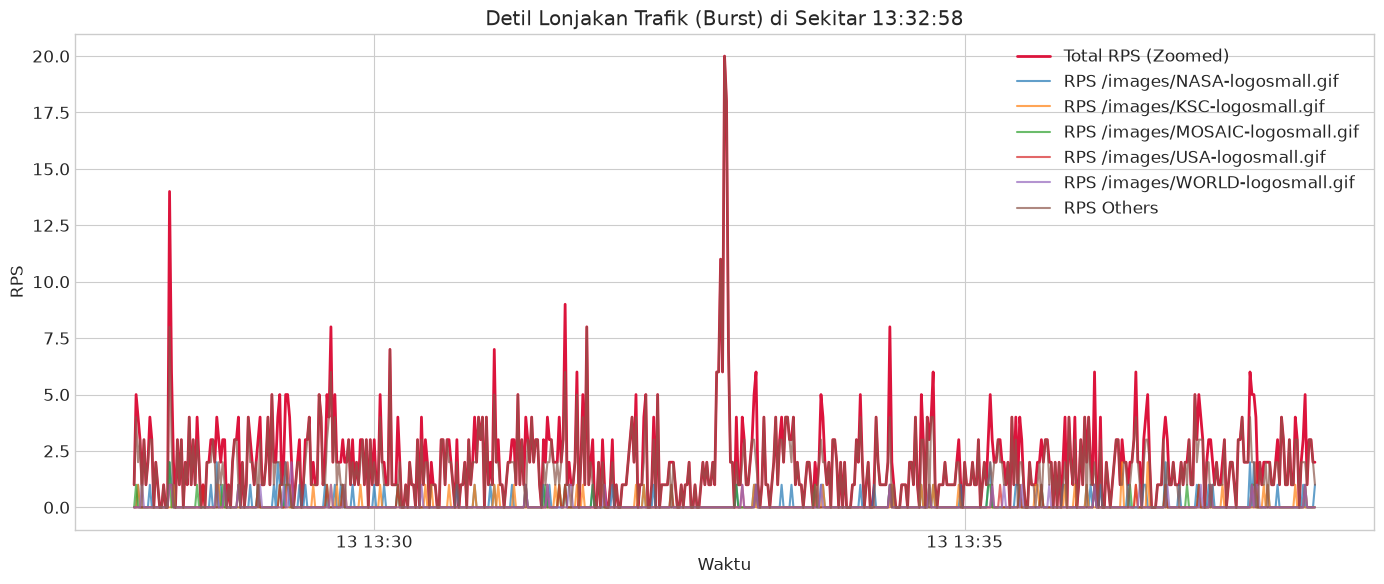

In [9]:
# Cari timestamp di mana terjadi lonjakan (peak)
peak_time = rps_df['total_rps'].idxmax()
print(f"Trafik puncak terjadi pada: {peak_time} dengan {rps_df['total_rps'].max()} RPS")

# Zoom ke area sekitar peak (+/- 5 menit)
zoom_start = peak_time - pd.Timedelta(minutes=5)
zoom_end = peak_time + pd.Timedelta(minutes=5)
zoomed_df = rps_df.loc[zoom_start:zoom_end]

plt.figure(figsize=(14, 6))
plt.plot(zoomed_df.index, zoomed_df['total_rps'], label='Total RPS (Zoomed)', color='crimson', linewidth=2)
for ep in plot_cols:
    plt.plot(zoomed_df.index, zoomed_df[ep], label=f'RPS {ep}', alpha=0.7)

plt.title(f'Detil Lonjakan Trafik (Burst) di Sekitar {peak_time:%H:%M:%S}')
plt.xlabel('Waktu')
plt.ylabel('RPS')
plt.legend()
plt.tight_layout()
plt.show()


In [10]:
# Simpan hasil agregasi ke file csv
output_csv_path = 'dataset/aggregated_rps.csv'
rps_df.to_csv(output_csv_path)
print(f"Dataset hasil agregasi per-detik berhasil disimpan ke: {output_csv_path}")


Dataset hasil agregasi per-detik berhasil disimpan ke: dataset/aggregated_rps.csv


## Kesimpulan & Formulasi Skenario Pengujian

Berdasarkan hasil analisis data log di atas:
1. **Workload Mix**: Pembagian distribusi request user tiruan di Locust dapat didasarkan pada persentase panggilan endpoint.
2. **Baseline RPS**: Gunakan nilai rata-rata (*mean*) RPS untuk pengujian performa normal.
3. **Peak/Burst RPS**: Skenario Stress Test (Spike Test) dirancang untuk melompat dari baseline menuju Peak RPS dalam waktu singkat.
